In [27]:
!pip -q install pandas numpy matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 50)

csv_path = Path('/content/yelp_review_sample_100k.csv')

df = pd.read_csv(csv_path)
print('Filas, columnas:', df.shape)

Filas, columnas: (100000, 9)


In [29]:
display(df.head(5))
print('\nTipos de datos:')
print(df.dtypes)

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,pFoKd6r3yl7GJjKcI0ncxQ,1abm-v8d6dZkSAAOCXLhwQ,ckbvLKwjEb836t-EDKsVVg,3.0,0,0,0,I've always left Abyssinia a bit disappointed....,2012-07-06 01:31:08
1,oQ0WYkQuQpkVGw4A76sH6Q,alF_72E35Q4bIsw5MXyZBQ,I81Ua5IltIBphFKnHmKwlg,5.0,2,0,0,Totally used my Groupon for a wonderful first ...,2010-03-17 19:13:29
2,nd0ULnXC5Qs_YA--ytuRjw,fBX6VKFlK29BOUT4bmX6EQ,vPDK-Pk-UTJV3ruTpqnYmQ,5.0,0,0,0,On 9/2/2021 while heading to the other side of...,2021-09-03 20:06:37
3,kJi4C-Oq-u6sC1akGR-GFg,BvyAFA1k8IY3t9HaMPx1dA,XBRCpC_oKlmyx-8hZrM74w,1.0,1,0,0,I had a clogged kitchen sink last March that t...,2019-01-28 21:25:13
4,wsoSs8aPbXFYHhYkhN30mw,fIj9bM2ynfptQ-qoj3qLOQ,NL_RDDQ_uPAT8t-x7hINvA,5.0,0,0,0,Ordered through Uber Eats. Soooo delicious. I ...,2019-10-15 23:11:18



Tipos de datos:
review_id       object
user_id         object
business_id     object
stars          float64
useful           int64
funny            int64
cool             int64
text            object
date            object
dtype: object


In [30]:
nulls = df.isna().sum().sort_values(ascending=False)
empty_text = (df['text'].astype(str).str.strip() == '').sum() if 'text' in df.columns else np.nan

quality = pd.DataFrame({
    'null_count': nulls,
    'null_pct': (nulls / len(df) * 100).round(3)
}).sort_values('null_count', ascending=False)

display(quality)
print(f'Textos vacíos (trim): {empty_text:,}')

,null_count,null_pct
review_id,0,0.0
user_id,0,0.0
business_id,0,0.0
stars,0,0.0
useful,0,0.0
funny,0,0.0
cool,0,0.0
text,0,0.0
date,0,0.0


Textos vacíos (trim): 0


In [31]:
dup_review_id = df.duplicated(subset=['review_id']).sum()
dup_full_row = df.duplicated().sum()
dup_text_exact = df.duplicated(subset=['text']).sum()

print(f'Duplicados por review_id: {dup_review_id:,}')
print(f'Duplicados de fila completa: {dup_full_row:,}')
print(f'Duplicados exactos por text: {dup_text_exact:,}')

Duplicados por review_id: 0
Duplicados de fila completa: 0
Duplicados exactos por text: 2


Fechas inválidas: 0
Rango temporal: 2005-03-08 05:16:12 -> 2022-01-19 19:35:57


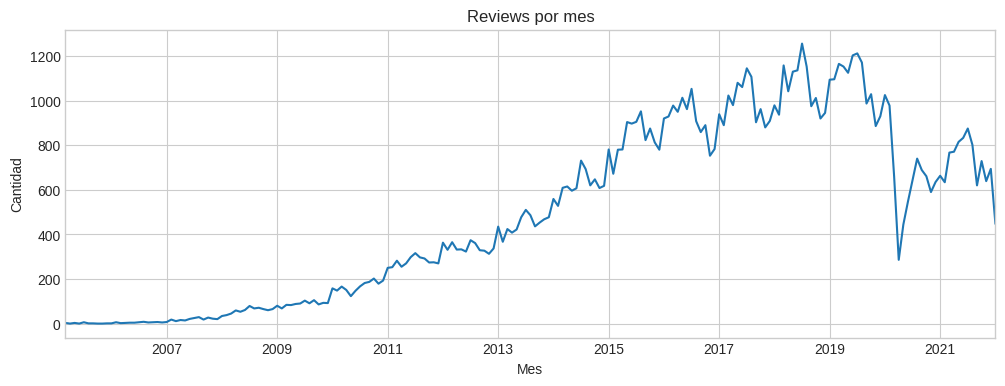

In [32]:
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
invalid_dates = df['date_parsed'].isna().sum()
print(f'Fechas inválidas: {invalid_dates:,}')

date_min = df['date_parsed'].min()
date_max = df['date_parsed'].max()
print('Rango temporal:', date_min, '->', date_max)

monthly = (
    df.dropna(subset=['date_parsed'])
      .set_index('date_parsed')
      .resample('ME')
      .size()
)

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax)
ax.set_title('Reviews por mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Cantidad')
plt.show()

,count,mean,std,min,25%,50%,75%,max
stars,100000.0,3.74577,1.478492,1.0,3.0,4.0,5.0,5.0
useful,100000.0,1.17322,2.995724,0.0,0.0,0.0,1.0,262.0
funny,100000.0,0.32289,1.641743,0.0,0.0,0.0,0.0,201.0
cool,100000.0,0.49795,2.225926,0.0,0.0,0.0,0.0,261.0


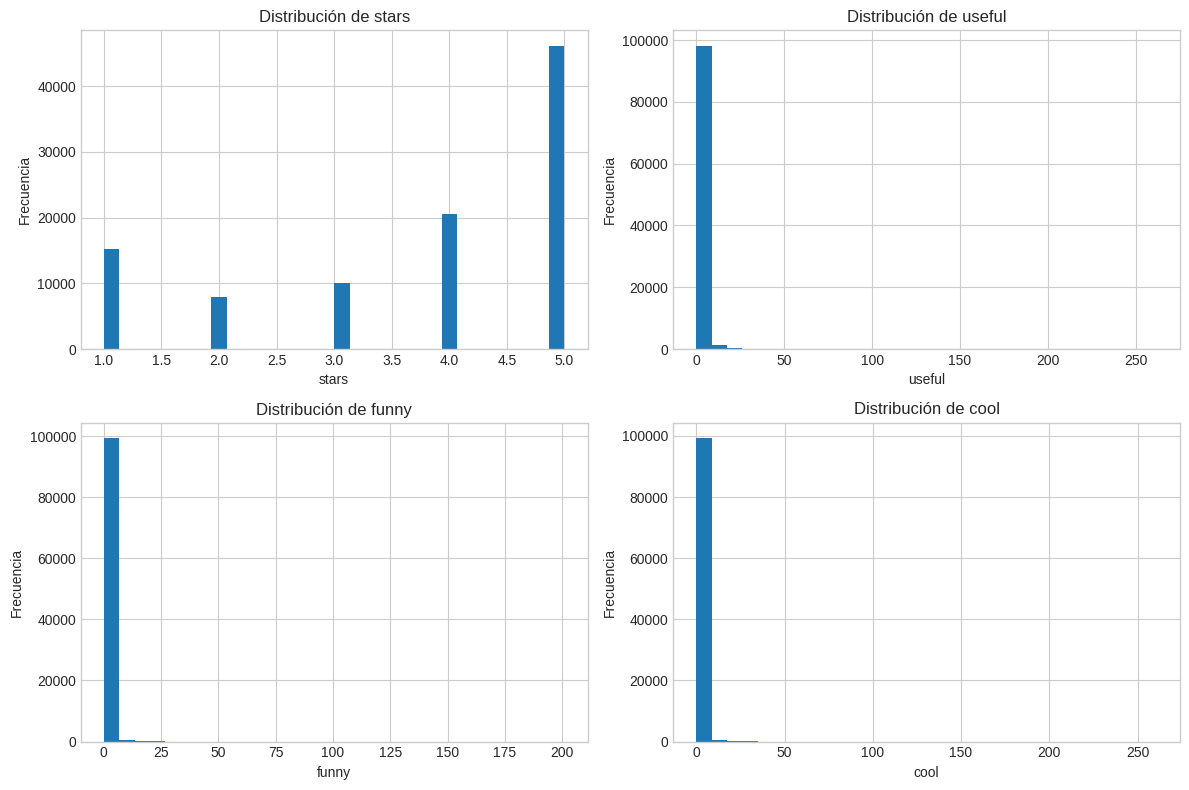

In [33]:
num_cols = ['stars', 'useful', 'funny', 'cool']
stats = df[num_cols].describe().T
display(stats)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, c in zip(axes.flatten(), num_cols):
    ax.hist(df[c].dropna(), bins=30)
    ax.set_title(f'Distribución de {c}')
    ax.set_xlabel(c)
    ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [34]:
txt = df['text'].astype(str)
df['text_len_chars'] = txt.str.len()
df['text_len_words'] = txt.str.split().str.len()
df['line_breaks'] = txt.str.count('\n')
df['has_url'] = txt.str.contains(r'http[s]?://|www\.', regex=True, case=False, na=False).astype(int)

def upper_ratio(s: str) -> float:
    letters = [ch for ch in s if ch.isalpha()]
    if not letters:
        return 0.0
    upper = sum(ch.isupper() for ch in letters)
    return upper / len(letters)

df['upper_ratio'] = txt.apply(upper_ratio)

display(df[['text_len_chars', 'text_len_words', 'line_breaks', 'has_url', 'upper_ratio']].describe().T)

,count,mean,std,min,25%,50%,75%,max
text_len_chars,100000.0,568.353260,529.463323,11.0,229.000000,403.000000,720.000000,5000.000000
text_len_words,100000.0,104.874730,98.381689,1.0,42.000000,74.000000,133.000000,1003.000000
line_breaks,100000.0,1.824590,3.711649,0.0,0.000000,0.000000,2.000000,120.000000
has_url,100000.0,0.001920,0.043776,0.0,0.000000,0.000000,0.000000,1.000000
upper_ratio,100000.0,0.036479,0.022859,0.0,0.024331,0.031621,0.042012,0.818966


In [35]:
text_counts = df.groupby('text', dropna=False).size().rename('text_freq').reset_index()
df = df.merge(text_counts, on='text', how='left')

tmp = df.dropna(subset=['date_parsed']).copy()
tmp['hour_bucket'] = tmp['date_parsed'].dt.floor('h')
user_hour_counts = (
    tmp.groupby(['user_id', 'hour_bucket'])
       .size()
       .rename('user_hour_freq')
       .reset_index()
)
tmp = tmp.merge(user_hour_counts, on=['user_id', 'hour_bucket'], how='left')

user_text_counts = (
    df.groupby(['user_id', 'text'])
      .size()
      .rename('user_same_text_freq')
      .reset_index()
)
df = df.merge(user_text_counts, on=['user_id', 'text'], how='left')

df['flag_text_repetition'] = (df['text_freq'] >= 3).astype(int)
df['flag_user_same_text'] = (df['user_same_text_freq'] >= 2).astype(int)

tmp['flag_user_burst_1h'] = (tmp['user_hour_freq'] >= 3).astype(int)

print('Conteo flag_text_repetition:', int(df['flag_text_repetition'].sum()))
print('Conteo flag_user_same_text:', int(df['flag_user_same_text'].sum()))
print('Conteo flag_user_burst_1h:', int(tmp['flag_user_burst_1h'].sum()))

Conteo flag_text_repetition: 0
Conteo flag_user_same_text: 4
Conteo flag_user_burst_1h: 30


In [36]:
suspicious = df[(df['flag_text_repetition'] == 1) | (df['flag_user_same_text'] == 1)].copy()
suspicious = suspicious.sort_values(['text_freq', 'user_same_text_freq'], ascending=False)

cols_show = [
    'review_id', 'user_id', 'business_id', 'stars', 'date',
    'text_freq', 'user_same_text_freq', 'text_len_chars', 'has_url', 'text'
]
display(suspicious[cols_show].head(20))

print('Total posibles sospechosos (reglas de repetición):', len(suspicious))

,review_id,user_id,business_id,stars,date,text_freq,user_same_text_freq,text_len_chars,has_url,text
25726,TPKEZkH5o1abiicLdhiBng,o9_Z0UTEVX9SZRy7Re5rQA,tmldiz-m9CNXZfiZglDGsA,5.0,2016-09-19 02:56:36,2,2,245,0,This is one of our favorite upscale/fancy rest...
74483,YERBSzGjbfKyfew0pYLAdw,-1xh43lAhmrByuMzcQ2sNw,vWyg7n0gGVinsrSj68GDeQ,4.0,2015-03-31 20:30:55,2,2,322,0,"The food was great, kinda overwhelming though...."
75979,1jYqQKGotpC5PyQ2-TSRzg,o9_Z0UTEVX9SZRy7Re5rQA,tmldiz-m9CNXZfiZglDGsA,5.0,2015-09-30 21:58:00,2,2,245,0,This is one of our favorite upscale/fancy rest...
99766,nD9Wwp3aDMIPk3andXUTTQ,-1xh43lAhmrByuMzcQ2sNw,vWyg7n0gGVinsrSj68GDeQ,4.0,2015-05-04 05:27:52,2,2,322,0,"The food was great, kinda overwhelming though...."


Total posibles sospechosos (reglas de repetición): 4
